In [1]:
import pickle
from pathlib import Path

out_dir = Path("/Users/javier/FLAMES_30dor/gausspy_validation")

FILENAME_DATA = out_dir / "real_FLAMES_validation_input.pickle"
FILENAME_DATA_DECOMP = out_dir / "real_FLAMES_validation_decomposed.pkl"
FILENAME_DF_VALIDATION = out_dir / "df_validation.pkl"
FILENAME_CONFIG = out_dir / "validation_training_config.pkl"

with open(FILENAME_DATA, "rb") as f:
    gauss_input = pickle.load(f)

with open(FILENAME_DATA_DECOMP, "rb") as f:
    data_decomp = pickle.load(f)

with open(FILENAME_DF_VALIDATION, "rb") as f:
    df_validation = pickle.load(f)

with open(FILENAME_CONFIG, "rb") as f:
    training_config = pickle.load(f)

print("gauss_input:", type(gauss_input))
print("data_decomp:", type(data_decomp))
print("df_validation:", type(df_validation))
print("training_config:", training_config)

gauss_input: <class 'dict'>
data_decomp: <class 'dict'>
df_validation: <class 'pandas.core.frame.DataFrame'>
training_config: {'phase': 'two', 'alpha1': 0.9, 'alpha2': 1.72, 'SNR_thresh': [10, 10], 'input_file': '/Users/javier/FLAMES_30dor/gausspy_validation/real_FLAMES_validation_input.pickle', 'decomposition_file': '/Users/javier/FLAMES_30dor/gausspy_validation/real_FLAMES_validation_decomposed.pkl', 'notes': 'FLAMES 30 Dor validation sample using trained GaussPy two-phase parameters.'}


In [2]:
import numpy as np
import pandas as pd


def make_validation_summary(
    gauss_input,
    data_decomp,
    lambda0_nm=656.28,
    rchi2_threshold=20,
    many_components_threshold=5,
):
    """
    Build a compact validation summary table for GaussPy decompositions.

    One row corresponds to one analyzed spectrum.

    Parameters
    ----------
    gauss_input : dict
        Input dictionary used for GaussPy decomposition. Must contain:
        'data_list', 'x_values', 'errors', and 'metadata'.

    data_decomp : dict
        Output dictionary returned by GaussPy batch_decomposition.

    lambda0_nm : float, default=656.28
        Rest wavelength used to convert fitted centers into velocity.
        For Halpha, lambda0_nm ≈ 656.28 nm.

    rchi2_threshold : float, default=20
        Threshold above which the fit is flagged as large chi-square.

    many_components_threshold : int, default=5
        Threshold above which the fit is flagged as having many components.

    Returns
    -------
    summary : pandas.DataFrame
        Validation summary table.
    """

    c_kms = 299792.458

    rows = []

    n_spectra = len(gauss_input["data_list"])

    for i in range(n_spectra):

        metadata = gauss_input["metadata"][i]

        wave = np.asarray(metadata["wave"], dtype=float)

        if len(wave) > 1:
            dw = np.nanmedian(np.diff(wave))
        else:
            dw = np.nan

        wave0 = wave[0] if len(wave) > 0 else np.nan
        wave_min = np.nanmin(wave) if len(wave) > 0 else np.nan
        wave_max = np.nanmax(wave) if len(wave) > 0 else np.nan

        means_fit_chan = np.asarray(data_decomp["means_fit"][i], dtype=float)
        fwhms_fit_chan = np.asarray(data_decomp["fwhms_fit"][i], dtype=float)
        amps_fit = np.asarray(data_decomp["amplitudes_fit"][i], dtype=float)

        means_initial = np.asarray(data_decomp["means_initial"][i], dtype=float)
        fwhms_initial = np.asarray(data_decomp["fwhms_initial"][i], dtype=float)
        amps_initial = np.asarray(data_decomp["amplitudes_initial"][i], dtype=float)

        means_fit_err_chan = np.asarray(data_decomp["means_fit_err"][i], dtype=float)
        fwhms_fit_err_chan = np.asarray(data_decomp["fwhms_fit_err"][i], dtype=float)
        amps_fit_err = np.asarray(data_decomp["amplitudes_fit_err"][i], dtype=float)

        ncomp_initial = len(means_initial)
        ncomp_fit = len(means_fit_chan)

        rchi2 = to_scalar(data_decomp["best_fit_rchi2"][i])

        # Convert channel quantities to wavelength quantities.
        means_fit_nm = wave0 + means_fit_chan * dw
        fwhms_fit_nm = fwhms_fit_chan * dw

        # Convert wavelength quantities to velocity quantities.
        means_fit_kms = c_kms * (means_fit_nm - lambda0_nm) / lambda0_nm
        fwhms_fit_kms = c_kms * fwhms_fit_nm / lambda0_nm

        # Basic automatic flags.
        flag_zero_components = ncomp_fit == 0
        flag_many_components = ncomp_fit > many_components_threshold
        flag_large_rchi2 = np.isfinite(rchi2) and rchi2 > rchi2_threshold

        if ncomp_fit > 0:
            flag_center_outside_window = np.any(
                (means_fit_nm < wave_min) | (means_fit_nm > wave_max)
            )
            flag_nonpositive_fwhm = np.any(fwhms_fit_chan <= 0)
        else:
            flag_center_outside_window = False
            flag_nonpositive_fwhm = False

        # Simple automatic quality label.
        if flag_zero_components:
            auto_quality = "zero_components"
        elif flag_nonpositive_fwhm:
            auto_quality = "nonpositive_fwhm"
        elif flag_center_outside_window:
            auto_quality = "center_outside_window"
        elif flag_large_rchi2:
            auto_quality = "large_rchi2"
        elif flag_many_components:
            auto_quality = "many_components"
        else:
            auto_quality = "ok_candidate"

        row = {
            # Identification
            "validation_index": metadata.get("validation_index", i),
            "filename": metadata.get("filename", None),
            "object": metadata.get("object", None),
            "ra_deg": metadata.get("ra_deg", None),
            "dec_deg": metadata.get("dec_deg", None),
            "sample": metadata.get("sample", None),

            # Wavelength window
            "wave_min_nm": wave_min,
            "wave_max_nm": wave_max,
            "dw_nm": dw,

            # Component counts
            "ncomp_initial": ncomp_initial,
            "ncomp_fit": ncomp_fit,

            # Fit quality
            "best_fit_rchi2": rchi2,

            # Raw GaussPy outputs in channel units
            "means_initial_chan": means_initial,
            "fwhms_initial_chan": fwhms_initial,
            "amps_initial": amps_initial,

            "means_fit_chan": means_fit_chan,
            "fwhms_fit_chan": fwhms_fit_chan,
            "amps_fit": amps_fit,

            "means_fit_err_chan": means_fit_err_chan,
            "fwhms_fit_err_chan": fwhms_fit_err_chan,
            "amps_fit_err": amps_fit_err,

            # Converted quantities
            "means_fit_nm": means_fit_nm,
            "fwhms_fit_nm": fwhms_fit_nm,
            "means_fit_kms": means_fit_kms,
            "fwhms_fit_kms": fwhms_fit_kms,

            # Automatic flags
            "flag_zero_components": flag_zero_components,
            "flag_many_components": flag_many_components,
            "flag_large_rchi2": flag_large_rchi2,
            "flag_center_outside_window": flag_center_outside_window,
            "flag_nonpositive_fwhm": flag_nonpositive_fwhm,
            "auto_quality": auto_quality,

            # Manual validation fields
            "visual_quality": "",
            "notes": "",
        }

        rows.append(row)

    summary = pd.DataFrame(rows)

    return summary


In [3]:
def to_scalar(value, default=np.nan):
    """
    Convert GaussPy scalar-like outputs to a float.

    Handles cases like:
    - 1.23
    - [1.23]
    - np.array([1.23])
    - None
    """
    if value is None:
        return default

    arr = np.asarray(value)

    if arr.size == 0:
        return default

    return float(arr.ravel()[0])

In [4]:
df_validation_summary = make_validation_summary(
    gauss_input,
    data_decomp,
    lambda0_nm=656.28,
    rchi2_threshold=20,
    many_components_threshold=5,
)

display(df_validation_summary.head())

,validation_index,filename,object,ra_deg,dec_deg,sample,wave_min_nm,wave_max_nm,dw_nm,ncomp_initial,...,means_fit_kms,fwhms_fit_kms,flag_zero_components,flag_many_components,flag_large_rchi2,flag_center_outside_window,flag_nonpositive_fwhm,auto_quality,visual_quality,notes
0,0,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,None,655.002319,657.997314,0.005005,4,...,"[261.4140001690211, -412.4001405310875, 294.13...","[54.32935838454545, 45.580404010895876, 76.328...",False,False,False,False,False,ok_candidate,,
1,1,ADP.2019-01-31T23_53_45.202.fits,u05,84.752833,-69.099972,None,655.002258,657.997253,0.005005,8,...,"[313.10663472833284, 299.48430368684484, 94.50...","[31.418103502972507, 74.52525273379153, 31.484...",False,True,False,False,False,many_components,,
2,2,ADP.2019-01-31T23_53_45.605.fits,t26,84.534833,-69.022194,None,655.002197,657.997192,0.005005,8,...,"[251.09557155250957, 268.40266055944574, -469....","[41.313724216327984, 92.26011207046, 395.09293...",False,True,False,False,False,many_components,,
3,3,ADP.2019-01-31T23_53_45.655.fits,u17,84.784000,-69.055528,None,655.002258,657.997253,0.005005,3,...,"[273.30136662120657, -413.8254469504506, 338.0...","[64.76290329081648, 36.889763454467285, 2141.7...",False,False,False,False,False,ok_candidate,,
4,4,ADP.2019-01-31T23_53_44.611.fits,u18,84.784000,-69.044417,None,655.002258,657.997253,0.005005,7,...,"[255.2478559609741, 301.07979849718294, 285.71...","[42.61941302630345, 49.12994047041794, 1871.47...",False,True,False,False,True,nonpositive_fwhm,,


In [5]:
print(df_validation_summary["auto_quality"].value_counts())
print(df_validation_summary["ncomp_fit"].value_counts().sort_index())

auto_quality
many_components          10
nonpositive_fwhm          8
ok_candidate              7
center_outside_window     5
Name: count, dtype: int64
ncomp_fit
3     2
4     2
5     7
6     1
7     5
8     7
9     3
10    2
11    1
Name: count, dtype: int64


In [6]:
from pathlib import Path
import pickle

out_dir = Path("/Users/javier/FLAMES_30dor/gausspy_validation")

FILENAME_SUMMARY = out_dir / "df_validation_summary.pkl"

with open(FILENAME_SUMMARY, "wb") as f:
    pickle.dump(df_validation_summary, f)

print("Saved:")
print(FILENAME_SUMMARY)

Saved:
/Users/javier/FLAMES_30dor/gausspy_validation/df_validation_summary.pkl


In [7]:
FILENAME_SUMMARY_CSV = out_dir / "df_validation_summary.csv"

df_validation_summary.to_csv(FILENAME_SUMMARY_CSV, index=False)

print("Saved:")
print(FILENAME_SUMMARY_CSV)

Saved:
/Users/javier/FLAMES_30dor/gausspy_validation/df_validation_summary.csv


In [8]:
#df_validation_summary.loc[0, "visual_quality"] = "good"
#df_validation_summary.loc[0, "notes"] = "Two components recovered; residuals acceptable."

In [9]:
import numpy as np

def add_velocity_columns_to_summary(
    df_summary,
    lambda0_nm=656.28,
    c_kms=299792.458,
):
    """
    Add velocity-space columns to a GaussPy validation summary table.

    Parameters
    ----------
    df_summary : pandas.DataFrame
        Summary table containing at least:
        'means_fit_nm' and 'fwhms_fit_nm'.

    lambda0_nm : float, default=656.28
        Rest wavelength of the emission line in nm.

    c_kms : float, default=299792.458
        Speed of light in km/s.

    Returns
    -------
    df_out : pandas.DataFrame
        Copy of the input dataframe with added velocity columns:
        'means_fit_kms' and 'fwhms_fit_kms'.
    """

    df_out = df_summary.copy()

    means_fit_kms = []
    fwhms_fit_kms = []

    for _, row in df_out.iterrows():

        means_nm = np.asarray(row["means_fit_nm"], dtype=float)
        fwhms_nm = np.asarray(row["fwhms_fit_nm"], dtype=float)

        v_centers = c_kms * (means_nm - lambda0_nm) / lambda0_nm
        v_fwhms = c_kms * fwhms_nm / lambda0_nm

        means_fit_kms.append(v_centers)
        fwhms_fit_kms.append(v_fwhms)

    df_out["means_fit_kms"] = means_fit_kms
    df_out["fwhms_fit_kms"] = fwhms_fit_kms
    df_out["lambda0_nm"] = lambda0_nm

    return df_out

In [10]:
df_validation_summary = add_velocity_columns_to_summary(
    df_validation_summary,
    lambda0_nm=656.28,
)

display(df_validation_summary.head())

,validation_index,filename,object,ra_deg,dec_deg,sample,wave_min_nm,wave_max_nm,dw_nm,ncomp_initial,...,fwhms_fit_kms,flag_zero_components,flag_many_components,flag_large_rchi2,flag_center_outside_window,flag_nonpositive_fwhm,auto_quality,visual_quality,notes,lambda0_nm
0,0,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,None,655.002319,657.997314,0.005005,4,...,"[54.32935838454545, 45.580404010895876, 76.328...",False,False,False,False,False,ok_candidate,,,656.28
1,1,ADP.2019-01-31T23_53_45.202.fits,u05,84.752833,-69.099972,None,655.002258,657.997253,0.005005,8,...,"[31.418103502972507, 74.52525273379153, 31.484...",False,True,False,False,False,many_components,,,656.28
2,2,ADP.2019-01-31T23_53_45.605.fits,t26,84.534833,-69.022194,None,655.002197,657.997192,0.005005,8,...,"[41.313724216327984, 92.26011207046, 395.09293...",False,True,False,False,False,many_components,,,656.28
3,3,ADP.2019-01-31T23_53_45.655.fits,u17,84.784000,-69.055528,None,655.002258,657.997253,0.005005,3,...,"[64.76290329081648, 36.889763454467285, 2141.7...",False,False,False,False,False,ok_candidate,,,656.28
4,4,ADP.2019-01-31T23_53_44.611.fits,u18,84.784000,-69.044417,None,655.002258,657.997253,0.005005,7,...,"[42.61941302630345, 49.12994047041794, 1871.47...",False,True,False,False,True,nonpositive_fwhm,,,656.28


In [11]:
cols_velocity = [
    "validation_index",
    "object",
    "ncomp_fit",
    "means_fit_nm",
    "fwhms_fit_nm",
    "means_fit_kms",
    "fwhms_fit_kms",
    "best_fit_rchi2",
    "auto_quality",
]

display(df_validation_summary[cols_velocity])

,validation_index,object,ncomp_fit,means_fit_nm,fwhms_fit_nm,means_fit_kms,fwhms_fit_kms,best_fit_rchi2,auto_quality
0,0,u31,4,"[656.852265163625, 655.3772088956696, 656.9238...","[0.11893318317103724, 0.09978072078207767, 0.1...","[261.4140001690211, -412.4001405310875, 294.13...","[54.32935838454545, 45.580404010895876, 76.328...",4.503184,ok_candidate
1,1,u05,8,"[656.9654262565855, 656.9356054149421, 656.486...","[0.06877782418038947, 0.1631443071997919, 0.06...","[313.10663472833284, 299.48430368684484, 94.50...","[31.418103502972507, 74.52525273379153, 31.484...",13.153088,many_components
2,2,t26,8,"[656.8296769425016, 656.8675641410297, 655.251...","[0.09044047041600936, 0.20196794393540576, 0.8...","[251.09557155250957, 268.40266055944574, -469....","[41.313724216327984, 92.26011207046, 395.09293...",1.235990,many_components
3,3,u17,3,"[656.8782879692262, 655.3740887367999, 657.020...","[0.14177340702712757, 0.08075591401267937, 4.6...","[273.30136662120657, -413.8254469504506, 338.0...","[64.76290329081648, 36.889763454467285, 2141.7...",2.925423,ok_candidate
4,4,u18,7,"[656.8387667682756, 656.9390981356767, 656.905...","[0.093298772649252, 0.10755106231500289, 4.096...","[255.2478559609741, 301.07979849718294, 285.71...","[42.61941302630345, 49.12994047041794, 1871.47...",2.778447,nonpositive_fwhm
5,5,u15,9,"[656.9259791784016, 656.9029341650526, 656.532...","[0.0728333467113269, 0.17057617535456795, 0.09...","[295.0869837719223, 284.5598898538609, 115.478...","[33.270689393178074, 77.9201726180669, 42.5775...",0.751573,nonpositive_fwhm
6,6,u29,8,"[656.7934713535062, 656.8779449904304, 656.883...","[0.07980937433115325, 0.08755545308251218, 0.1...","[234.55665139913575, 273.1446919453795, 275.47...","[36.4573787136261, 39.995831795742674, 86.6736...",0.865447,many_components
7,7,t47,10,"[656.8954409480286, 656.8918538764183, 656.775...","[0.18851931006726952, 0.07425764083680225, 0.0...","[281.13694545523737, 279.49835062514927, 226.1...","[86.11669919170305, 33.92131509682776, 34.4321...",0.567627,center_outside_window
8,8,t29,11,"[656.8455617309619, 656.9939862754584, 656.913...","[0.06792880459035106, 0.0695302769655894, 0.16...","[258.35183378406765, 326.15301471619097, 289.2...","[31.030266497749473, 31.761828239371653, 76.62...",2.224849,many_components
9,9,u37,8,"[656.9120419182508, 656.8822449377822, 656.685...","[0.08908981746148933, 0.22365047723773157, 0.0...","[288.7203636122516, 275.10893249189274, 185.34...","[40.696738220806985, 102.16481730964314, 28.31...",1.837678,nonpositive_fwhm


In [12]:
import pandas as pd
import numpy as np

def make_component_table(df_summary):
    """
    Convert the validation summary table into a component-level table.

    One row corresponds to one fitted Gaussian component.
    """

    rows = []

    for _, row in df_summary.iterrows():

        ncomp = int(row["ncomp_fit"])

        means_nm = np.asarray(row["means_fit_nm"], dtype=float)
        fwhms_nm = np.asarray(row["fwhms_fit_nm"], dtype=float)
        amps = np.asarray(row["amps_fit"], dtype=float)

        means_kms = np.asarray(row["means_fit_kms"], dtype=float)
        fwhms_kms = np.asarray(row["fwhms_fit_kms"], dtype=float)

        for j in range(ncomp):
            rows.append({
                "validation_index": row["validation_index"],
                "component_index": j,
                "filename": row["filename"],
                "object": row["object"],
                "ra_deg": row["ra_deg"],
                "dec_deg": row["dec_deg"],
                "ncomp_fit": ncomp,
                "best_fit_rchi2": row["best_fit_rchi2"],
                "auto_quality": row["auto_quality"],
                "visual_quality": row.get("visual_quality", ""),
                "mean_nm": means_nm[j],
                "fwhm_nm": fwhms_nm[j],
                "mean_kms": means_kms[j],
                "fwhm_kms": fwhms_kms[j],
                "amp": amps[j],
            })

    return pd.DataFrame(rows)

In [13]:
df_components = make_component_table(df_validation_summary)

display(df_components.head())
print("Number of fitted components:", len(df_components))

,validation_index,component_index,filename,object,ra_deg,dec_deg,ncomp_fit,best_fit_rchi2,auto_quality,visual_quality,mean_nm,fwhm_nm,mean_kms,fwhm_kms,amp
0,0,0,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,656.852265,0.118933,261.414000,54.329358,2169.375435
1,0,1,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,655.377209,0.099781,-412.400141,45.580404,153.544696
2,0,2,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,656.923891,0.167092,294.133279,76.328589,177.439525
3,0,3,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,657.171694,4.691754,407.331134,2143.220259,20.322111
4,1,0,ADP.2019-01-31T23_53_45.202.fits,u05,84.752833,-69.099972,8,13.153088,many_components,,656.965426,0.068778,313.106635,31.418104,10006.292803


Number of fitted components: 204


In [14]:
df_components

,validation_index,component_index,filename,object,ra_deg,dec_deg,ncomp_fit,best_fit_rchi2,auto_quality,visual_quality,mean_nm,fwhm_nm,mean_kms,fwhm_kms,amp
0,0,0,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,656.852265,0.118933,261.414000,54.329358,2169.375435
1,0,1,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,655.377209,0.099781,-412.400141,45.580404,153.544696
2,0,2,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,656.923891,0.167092,294.133279,76.328589,177.439525
3,0,3,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,657.171694,4.691754,407.331134,2143.220259,20.322111
4,1,0,ADP.2019-01-31T23_53_45.202.fits,u05,84.752833,-69.099972,8,13.153088,many_components,,656.965426,0.068778,313.106635,31.418104,10006.292803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,29,0,ADP.2019-01-31T23_53_42.736.fits,t60,84.799583,-69.177750,5,2.516251,nonpositive_fwhm,,656.840806,0.071318,256.179422,32.578528,4739.883018
200,29,1,ADP.2019-01-31T23_53_42.736.fits,t60,84.799583,-69.177750,5,2.516251,nonpositive_fwhm,,656.878753,0.150430,273.513600,68.717163,829.152014
201,29,2,ADP.2019-01-31T23_53_42.736.fits,t60,84.799583,-69.177750,5,2.516251,nonpositive_fwhm,,655.365991,0.052708,-417.524558,24.077444,249.069825
202,29,3,ADP.2019-01-31T23_53_42.736.fits,t60,84.799583,-69.177750,5,2.516251,nonpositive_fwhm,,657.932714,11.305762,754.969260,5164.536710,12.991391


In [15]:
display(df_components[[
    "validation_index",
    "component_index",
    "object",
    "mean_kms",
    "fwhm_kms",
    "amp",
    "best_fit_rchi2",
    "auto_quality",
]])

,validation_index,component_index,object,mean_kms,fwhm_kms,amp,best_fit_rchi2,auto_quality
0,0,0,u31,261.414000,54.329358,2169.375435,4.503184,ok_candidate
1,0,1,u31,-412.400141,45.580404,153.544696,4.503184,ok_candidate
2,0,2,u31,294.133279,76.328589,177.439525,4.503184,ok_candidate
3,0,3,u31,407.331134,2143.220259,20.322111,4.503184,ok_candidate
4,1,0,u05,313.106635,31.418104,10006.292803,13.153088,many_components
...,...,...,...,...,...,...,...,...
199,29,0,t60,256.179422,32.578528,4739.883018,2.516251,nonpositive_fwhm
200,29,1,t60,273.513600,68.717163,829.152014,2.516251,nonpositive_fwhm
201,29,2,t60,-417.524558,24.077444,249.069825,2.516251,nonpositive_fwhm
202,29,3,t60,754.969260,5164.536710,12.991391,2.516251,nonpositive_fwhm


In [16]:
df_components

,validation_index,component_index,filename,object,ra_deg,dec_deg,ncomp_fit,best_fit_rchi2,auto_quality,visual_quality,mean_nm,fwhm_nm,mean_kms,fwhm_kms,amp
0,0,0,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,656.852265,0.118933,261.414000,54.329358,2169.375435
1,0,1,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,655.377209,0.099781,-412.400141,45.580404,153.544696
2,0,2,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,656.923891,0.167092,294.133279,76.328589,177.439525
3,0,3,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,657.171694,4.691754,407.331134,2143.220259,20.322111
4,1,0,ADP.2019-01-31T23_53_45.202.fits,u05,84.752833,-69.099972,8,13.153088,many_components,,656.965426,0.068778,313.106635,31.418104,10006.292803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,29,0,ADP.2019-01-31T23_53_42.736.fits,t60,84.799583,-69.177750,5,2.516251,nonpositive_fwhm,,656.840806,0.071318,256.179422,32.578528,4739.883018
200,29,1,ADP.2019-01-31T23_53_42.736.fits,t60,84.799583,-69.177750,5,2.516251,nonpositive_fwhm,,656.878753,0.150430,273.513600,68.717163,829.152014
201,29,2,ADP.2019-01-31T23_53_42.736.fits,t60,84.799583,-69.177750,5,2.516251,nonpositive_fwhm,,655.365991,0.052708,-417.524558,24.077444,249.069825
202,29,3,ADP.2019-01-31T23_53_42.736.fits,t60,84.799583,-69.177750,5,2.516251,nonpositive_fwhm,,657.932714,11.305762,754.969260,5164.536710,12.991391


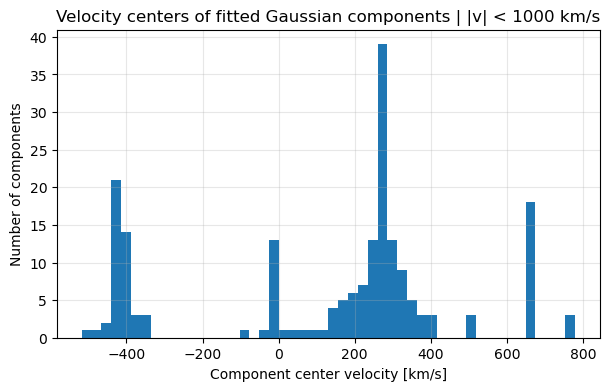

In [19]:
import matplotlib.pyplot as plt

vel = df_components["mean_kms"]

vel_filtered = vel[np.abs(vel) < 1000]

plt.figure(figsize=(7, 4))
plt.hist(vel_filtered, bins=50)
plt.xlabel("Component center velocity [km/s]")
plt.ylabel("Number of components")
plt.title("Velocity centers of fitted Gaussian components | |v| < 1000 km/s")
plt.grid(alpha=0.3)
plt.show()

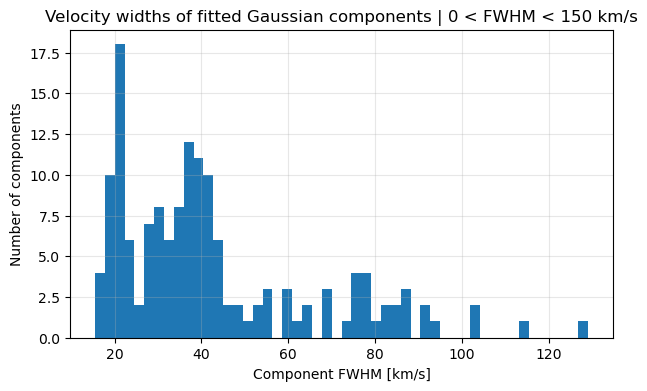

In [20]:
fwhm = df_components["fwhm_kms"]

fwhm_filtered = fwhm[(fwhm > 0) & (fwhm < 150)]

plt.figure(figsize=(7, 4))
plt.hist(fwhm_filtered, bins=50)
plt.xlabel("Component FWHM [km/s]")
plt.ylabel("Number of components")
plt.title("Velocity widths of fitted Gaussian components | 0 < FWHM < 150 km/s")
plt.grid(alpha=0.3)
plt.show()